In [1]:
import json
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import numpy as np
from scipy.stats import ttest_ind
from scipy.interpolate import interp1d, barycentric_interpolate

import pandas as pd

from fooof.core.funcs import expo_const_function, expo_double_const_function
from timescales.fit import PSD
from timescales.plts import set_default_rc
from ad_organoids.spectral import compute_spectra_windows

set_default_rc()

# 02. Group Comparisons

This notebook compares aperiodic parameters for a double knee model between WT/WT and WT/delE9 organoids at the mid timepoint. A double knee aperiodic model has been implemented to fit the spectra. The results show that the WT/delE9 organods have a faster timescale (171 vs 225 Hertz) compared to the WT/WT organoids. 

In [2]:
# Paths
dirpath = '/home/rphammonds/projects/ad_organoids'
meta_path = f'{dirpath}/data/plate4/meta.json'
spectra_path = f'{dirpath}/spectra/plate4/plate4_midpoint_00/ar'

# Load meta data
with open(meta_path) as json_file:
    meta = json.load(json_file)
    
# Unpack dict
fs = meta['fs'] * 1000
scale = meta['scale']
wells = np.array(meta['well_labels'])

In [3]:
# Load freqs and powers
freqs = np.load(f"{spectra_path}/freqs.npz")['arr_0']
powers = np.load(f"{spectra_path}/powers.npz")['arr_0']

# Mean signal per well (across 16 electrodes)
powers_mean_per_well = np.mean(powers, axis=(-3, -2))

# Reshape to 2d
orig_shape = powers_mean_per_well.shape

powers_mean_per_well = powers_mean_per_well.reshape(-1, orig_shape[-1])

In [4]:
# Constrained optimziation
bounds = [[-10, 1e-3,  0, 0, -10, 20,    0, 0],
          [ 10,   20, 10, 1,  10, 1000, 10, 1]]

guess = [1,    1, 2, 0,
         1,  100, 2, 0]

# Fit
psd = PSD(freqs=freqs, powers=powers_mean_per_well)

psd.fit(ap_mode='double', method='cauchy', n_resample=1000, bounds=bounds,
        guess=guess, n_jobs=-1, progress='tqdm.notebook', maxfev=10000)

# Organize results
well_row_wt, well_col_wt = np.where(wells == 'WT/WT')
well_row_del, well_col_del = np.where(wells == 'WT/delE9')

powers_mean_per_well = powers_mean_per_well.reshape(orig_shape)
powers_wt = powers_mean_per_well[:, well_row_wt, well_col_wt].reshape(-1, orig_shape[-1])
powers_del = powers_mean_per_well[:, well_row_del, well_col_del].reshape(-1, orig_shape[-1])

Fitting PSD:   0%|          | 0/7104 [00:00<?, ?it/s]

## Results

### Example Fit

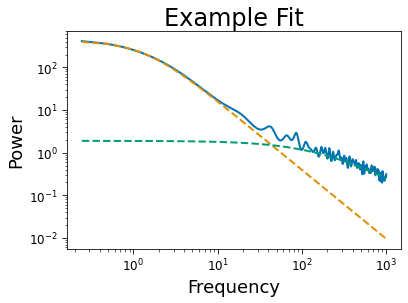

In [6]:
plt.figure(0)
ind = 2
plt.plot(psd.freqs, psd.powers[ind])
for p in psd.params[ind].reshape(2, -1):
    plt.loglog(psd.freqs, 10**expo_const_function(psd.freqs, *p), ls='--')
    
plt.title('Example Fit')
plt.ylabel('Power')
plt.xlabel('Frequency');

## R-Squared

Ttest_indResult(statistic=15.013861834570031, pvalue=3.4881193007955963e-50)

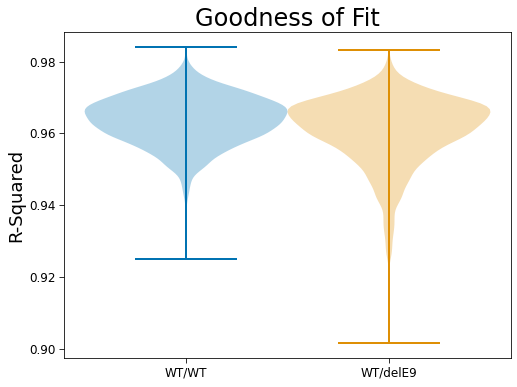

In [7]:
# Plot r-squared
rsq = psd.rsq.reshape(*orig_shape[:-1], -1)

rsq_wt = rsq[:, well_row_wt, well_col_wt].reshape(-1)
rsq_del = rsq[:, well_row_del, well_col_del].reshape(-1)

plt.figure(figsize=(8, 6))
plt.title('Goodness of Fit')
plt.violinplot(rsq_wt, positions=[1])
plt.violinplot(rsq_del, positions=[1.5])
plt.xticks([1, 1.5], ['WT/WT', 'WT/delE9'])
plt.ylabel('R-Squared');

ttest_ind(rsq_wt, rsq_del)

## Model Parameters

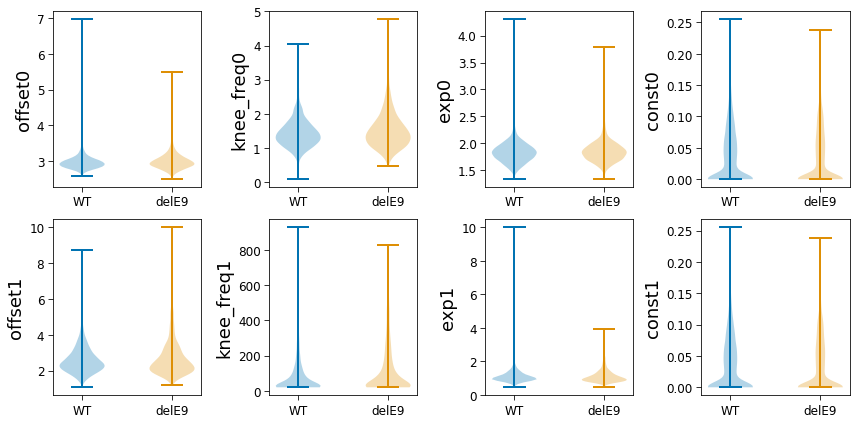

In [8]:
# Reshape parameters
params = psd.params.reshape(*orig_shape[:-1], -1)

params_wt = params[:, well_row_wt, well_col_wt].reshape(-1, 8)
params_del = params[:, well_row_del, well_col_del].reshape(-1, 8)

param_names = [p + j for j in ['0', '1'] for p in psd.param_names]
inds = [(i, j) for i in range(2) for j in range(4)]

# Plot
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 6))

for i in range(8):
    ax_inds = inds[i]
    axes[ax_inds].violinplot(params_wt[:, i])
    axes[ax_inds].violinplot(params_del[:, i], positions=[2])
    axes[ax_inds].set_ylabel(param_names[i])
    axes[ax_inds].set_xticks([1, 2], ['WT', 'delE9'])
    
plt.tight_layout()

## Stats

In [9]:
# Stats
nround = 6

pmeans_wt = []
pstds_wt = []
pmeans_del = []
pstds_del = []
tstats = []
pvals = []

for i in range(8):
    
    p0, p1 = params_wt[:, i], params_del[:, i]
    
    pmeans_wt.append(p0.mean().round(nround))
    pmeans_del.append(p1.mean().round(nround))
    
    pstds_wt.append(p0.std().round(nround))
    pstds_del.append(p1.std().round(nround))
    
    t, p = ttest_ind(p0, p1)
    
    tstats.append(t)
    pvals.append(p)
    
# Organize into dataframe
df = pd.DataFrame()

df['Parameter'] = param_names
df['Mean (std.) WT/WT'] = [f"{m} ({s})" for m, s in
                           zip(pmeans_wt, pstds_wt)]

df['Mean (std.) WT/delE9'] = [f"{m} ({s})" for m, s in
                              zip(pmeans_del, pstds_del)]

df['tstat'] = np.array(tstats).round(nround)
df['pvalue'] = np.array(pvals).round(nround)

df

,Parameter,Mean (std.) WT/WT,Mean (std.) WT/delE9,tstat,pvalue
0,offset0,2.953869 (0.193471),2.987753 (0.249078),-6.402061,0.000000
1,knee_freq0,1.439425 (0.436669),1.521909 (0.533644),-7.128441,0.000000
2,exp0,1.826079 (0.183777),1.851365 (0.210611),-5.390820,0.000000
3,const0,0.037018 (0.042025),0.032881 (0.040355),4.231373,0.000024
4,offset1,2.629813 (0.806805),2.752821 (1.078729),-5.441494,0.000000
5,knee_freq1,89.96107 (112.05257),125.204672 (144.735138),-11.473794,0.000000
6,exp1,1.103665 (0.340165),1.132083 (0.39951),-3.227366,0.001255
7,const1,0.037015 (0.042012),0.032883 (0.040345),4.227359,0.000024


## Timescale Variation

Each trace is the mean of 16 electrodes per well. There are 24 wells (traces) per WT/WT and WT/delE9.

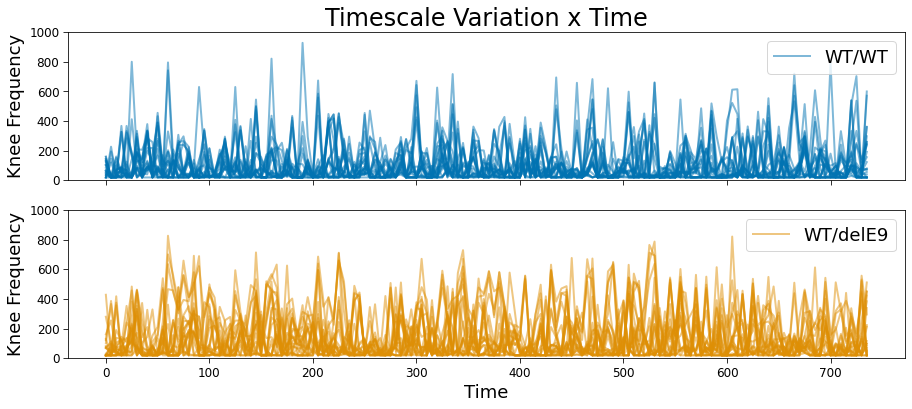

In [10]:
fig, axes = plt.subplots(nrows=2, figsize=(15, 6), sharex=True)

kf1 = psd.params[:, 5]
kf1 = kf1.reshape(*orig_shape[:-1])

times = np.arange(0, len(kf1) * 5, 5)

label0 = 'WT/WT'
label1 = 'WT/delE9'
            
for wr in range(6):
    for wc in range(8):    
        if wells[wr, wc] == 'WT/WT':
            axes[0].plot(times, kf1[:, wr, wc],  label=label0,
                         color='C0', alpha=.5)
            label0 = ''
        else:
            axes[1].plot(times, kf1[:, wr, wc], label=label1,
                         color='C1', alpha=.5)
            label1 = ''
            
axes[0].set_ylim(0, 1000)
axes[1].set_ylim(0, 1000)
axes[0].set_title('Timescale Variation x Time')
axes[0].set_ylabel('Knee Frequency')
axes[1].set_ylabel('Knee Frequency')
axes[1].set_xlabel('Time')
axes[0].legend(loc='upper right');
axes[1].legend(loc='upper right');

## Slow vs Fast Timescales

In [27]:
# Organize spectral results
_powers = psd.powers.reshape(*orig_shape[:-1], -1)
_powers_fit = psd.powers_fit.reshape(*orig_shape[:-1], -1)
_params = psd.params.reshape(*orig_shape[:-1], 8)

powers_wt = np.zeros((3, 148, 24, psd.powers.shape[-1]))
powers_del = np.zeros((3, 148, 24, psd.powers.shape[-1]))

for wr in range(6):
    for wc in range(8):
        for ind in range(len(_powers)):
            if wells[wr, wc] == 'WT/WT':
                powers_wt[0][ind] = _powers[ind, wr, wc]
                powers_wt[1][ind] = 10**expo_const_function(psd.freqs, *_params[ind, wr, wc][-4:])
                powers_wt[2][ind] = 10**expo_const_function(psd.freqs, *_params[ind, wr, wc][:4])
            else:
                powers_del[0][ind] = _powers[ind, wr, wc]
                powers_del[1][ind] = 10**expo_const_function(psd.freqs, *_params[ind, wr, wc][-4:])
                powers_del[2][ind] = 10**expo_const_function(psd.freqs, *_params[ind, wr, wc][:4])

powers_wt = powers_wt.mean(axis=2)
powers_del = powers_del.mean(axis=2)

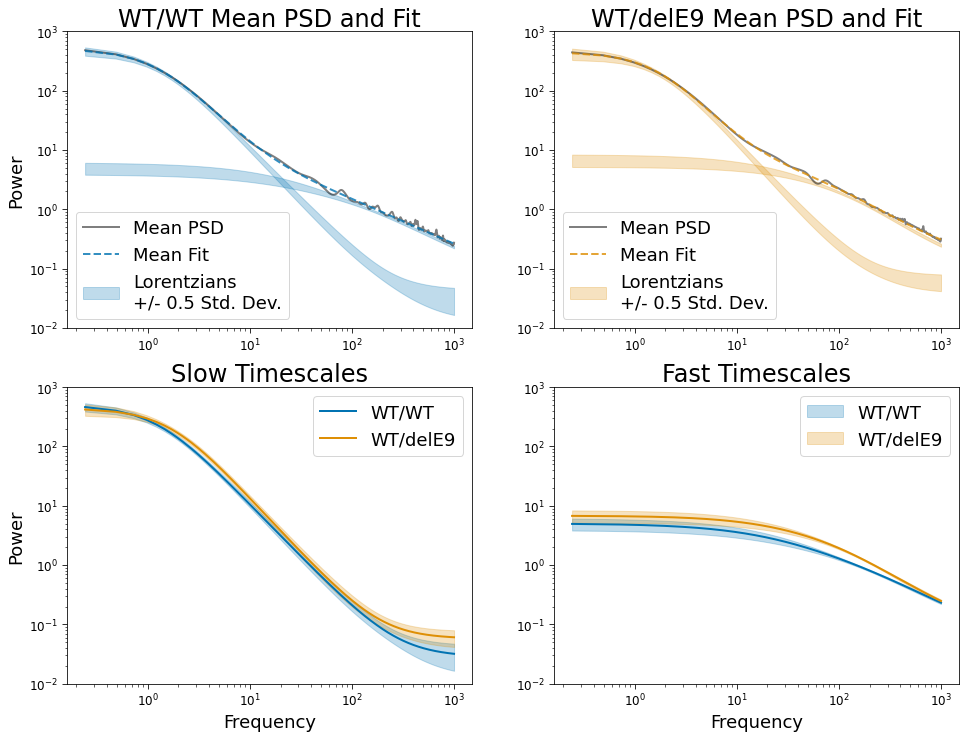

In [29]:
# Plot
fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(16, 12))

std = .5

# WT/WT
axes[0][0].loglog(psd.freqs, powers_wt[0].mean(axis=0), color='k',
                  alpha=.5, lw=2, ls='solid', label='Mean PSD')

axes[0][0].loglog(psd.freqs, (powers_wt[1] + powers_wt[2]).mean(axis=0), color='C0',
                  alpha=.8, lw=2, ls='--', label='Mean Fit')

for i in range(2):
    #axes[0][0].loglog(psd.freqs, powers_wt[i+1].mean(axis=0), color='C0', alpha=.5)
    pmean = powers_wt[i+1].mean(axis=0)
    pstd = powers_wt[i+1].std(axis=0) * std
    label = 'Lorentzians\n+/- 0.5 Std. Dev.' if i == 0 else ''
    axes[0][0].fill_between(psd.freqs, pmean-pstd, pmean+pstd,
                            alpha=.25, color='C0', label=label)
    
# WT/delE9
axes[0][1].loglog(psd.freqs, powers_del[0].mean(axis=0), color='k',
                  alpha=.5, lw=2, ls='solid', label='Mean PSD')

axes[0][1].loglog(psd.freqs, (powers_del[1] + powers_del[2]).mean(axis=0), color='C1',
                  alpha=.8, lw=2, ls='--', label='Mean Fit')
for i in range(2):
    #axes[0][1].loglog(psd.freqs, powers_del[i+1].mean(axis=0), color='C1', alpha=.5)
    pmean = powers_del[i+1].mean(axis=0)
    pstd = powers_del[i+1].std(axis=0) * std
    label = 'Lorentzians\n+/- 0.5 Std. Dev.' if i == 0 else ''
    axes[0][1].fill_between(psd.freqs, pmean-pstd, pmean+pstd,
                            alpha=.25, color='C1', label=label)


# Bottom left
axes[1][0].loglog(psd.freqs, powers_wt[2].mean(axis=0),
                  color='C0', label='WT/WT')
pmean = powers_wt[2].mean(axis=0)
pstd = powers_wt[2].std(axis=0) * std
axes[1][0].fill_between(psd.freqs, pmean-pstd, pmean+pstd, alpha=.25, color='C0')

axes[1][0].loglog(psd.freqs, powers_del[2].mean(axis=0),
                  color='C1', label='WT/delE9')
pmean = powers_del[2].mean(axis=0)
pstd = powers_del[2].std(axis=0) * std
axes[1][0].fill_between(psd.freqs, pmean-pstd, pmean+pstd, alpha=.25, color='C1')

# Bottom right
axes[1][1].loglog(psd.freqs, powers_wt[1].mean(axis=0), color='C0')
pmean = powers_wt[1].mean(axis=0)
pstd = powers_wt[1].std(axis=0) * std
axes[1][1].fill_between(psd.freqs, pmean-pstd, pmean+pstd, alpha=.25,
                        color='C0', label='WT/WT')

axes[1][1].loglog(psd.freqs, powers_del[1].mean(axis=0), color='C1')
pmean = powers_del[1].mean(axis=0)
pstd = powers_del[1].std(axis=0) * std
axes[1][1].fill_between(psd.freqs, pmean-pstd, pmean+pstd, alpha=.25,
                        color='C1', label='WT/delE9')

axes[0][0].set_title('WT/WT Mean PSD and Fit')
axes[0][1].set_title('WT/delE9 Mean PSD and Fit')
axes[1][0].set_title('Slow Timescales')
axes[1][1].set_title('Fast Timescales')

axes[0][0].set_ylim(1e-2, 1e3)
axes[0][1].set_ylim(1e-2, 1e3)
axes[1][0].set_ylim(1e-2, 1e3)
axes[1][1].set_ylim(1e-2, 1e3)

axes[0][0].legend()
axes[0][1].legend()
axes[1][0].legend()
axes[1][1].legend()

axes[1][0].set_xlabel('Frequency')
axes[1][1].set_xlabel('Frequency')
axes[0][0].set_ylabel('Power')
axes[1][0].set_ylabel('Power');
plt.savefig('summary.png', facecolor='white')